# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = '202643002@alu.comillas.edu'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/202643002@alu.comillas.edu/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# TODO: Carga el dataset Iris y explora su estructura.
# Pistas:
# - Usa datasets.load_iris()
# - Crea un DataFrame con dataset.data y dataset.feature_names
# - Añade la columna target/especie
# - Muestra shape, clases, primeras filas y estadísticas descriptivas

# dataset = ...
# df = ...
# df['species'] = ...
# df.head()
# Carga del dataset Iris y exploración de su estructura

dataset = datasets.load_iris()

df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Dimensiones del dataset (shape): {df.shape}")
print("\nDistribución de clases:")
print(df['species_name'].value_counts())

print("\nPrimeras 5 filas:")
display(df.head())

print("\nEstadísticas descriptivas:")
display(df.describe())


Dimensiones del dataset (shape): (150, 6)

Distribución de clases:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Primeras 5 filas:


{"ts": "2026-10-02 15:08:03.050", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjcwMDA0ODc3MTE3MDg2MhABIAEyJDAxYTBmZDI3LWY3OTQtNzJjYy1hNTI2LWVjMGRhZDk4Yzc3NTokMTBmOWJlNTEtM2MxMS0zNzM1LWJmYzYtNDA5NDlkYjhhNzU1SgsIspH/1QYQgLK2IFABWAFgAWiNorLmm8WjDYgBAA==.", "context": {}}
{"ts": "2026-10-02 15:08:03.050", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjcwMDA0ODc3MTE3MDg2MhABIAEyJDAxYTBmZDI3LWY3OTQtNzJjYy1hNTI2LWVjMGRhZDk4Yzc3NTokMTBmOWJlNTEtM2MxMS0zNzM1LWJmYzYtNDA5NDlkYjhhNzU1SgsIspH/1QYQgLK2IFABWAFgAWiNorLmm8WjDYgBAA==.", "context": {}}
{"ts": "2026-10-02 15:08:03.050", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjcwMDA0ODc3MTE3MDg2MhABIAEyJDAxYTBmZDI3LWY3OTQtNzJjYy1hNTI2LWVjMGRhZDk4Yzc3NTokMTBmOWJlNTEtM2MxMS0zNzM1LWJmYzYtNDA5NDlk

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
5.1,3.5,1.4,0.2,0,setosa
4.9,3.0,1.4,0.2,0,setosa
4.7,3.2,1.3,0.2,0,setosa
4.6,3.1,1.5,0.2,0,setosa
5.0,3.6,1.4,0.2,0,setosa



Estadísticas descriptivas:


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
150.0,150.0,150.0,150.0,150.0
5.843333333333334,3.0573333333333337,3.7580000000000005,1.1993333333333336,1.0
0.828066127977863,0.4358662849366982,1.7652982332594662,0.7622376689603465,0.8192319205190405
4.3,2.0,1.0,0.1,0.0
5.1,2.8,1.6,0.3,0.0
5.8,3.0,4.35,1.3,1.0
6.4,3.3,5.1,1.8,2.0
7.9,4.4,6.9,2.5,2.0


### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

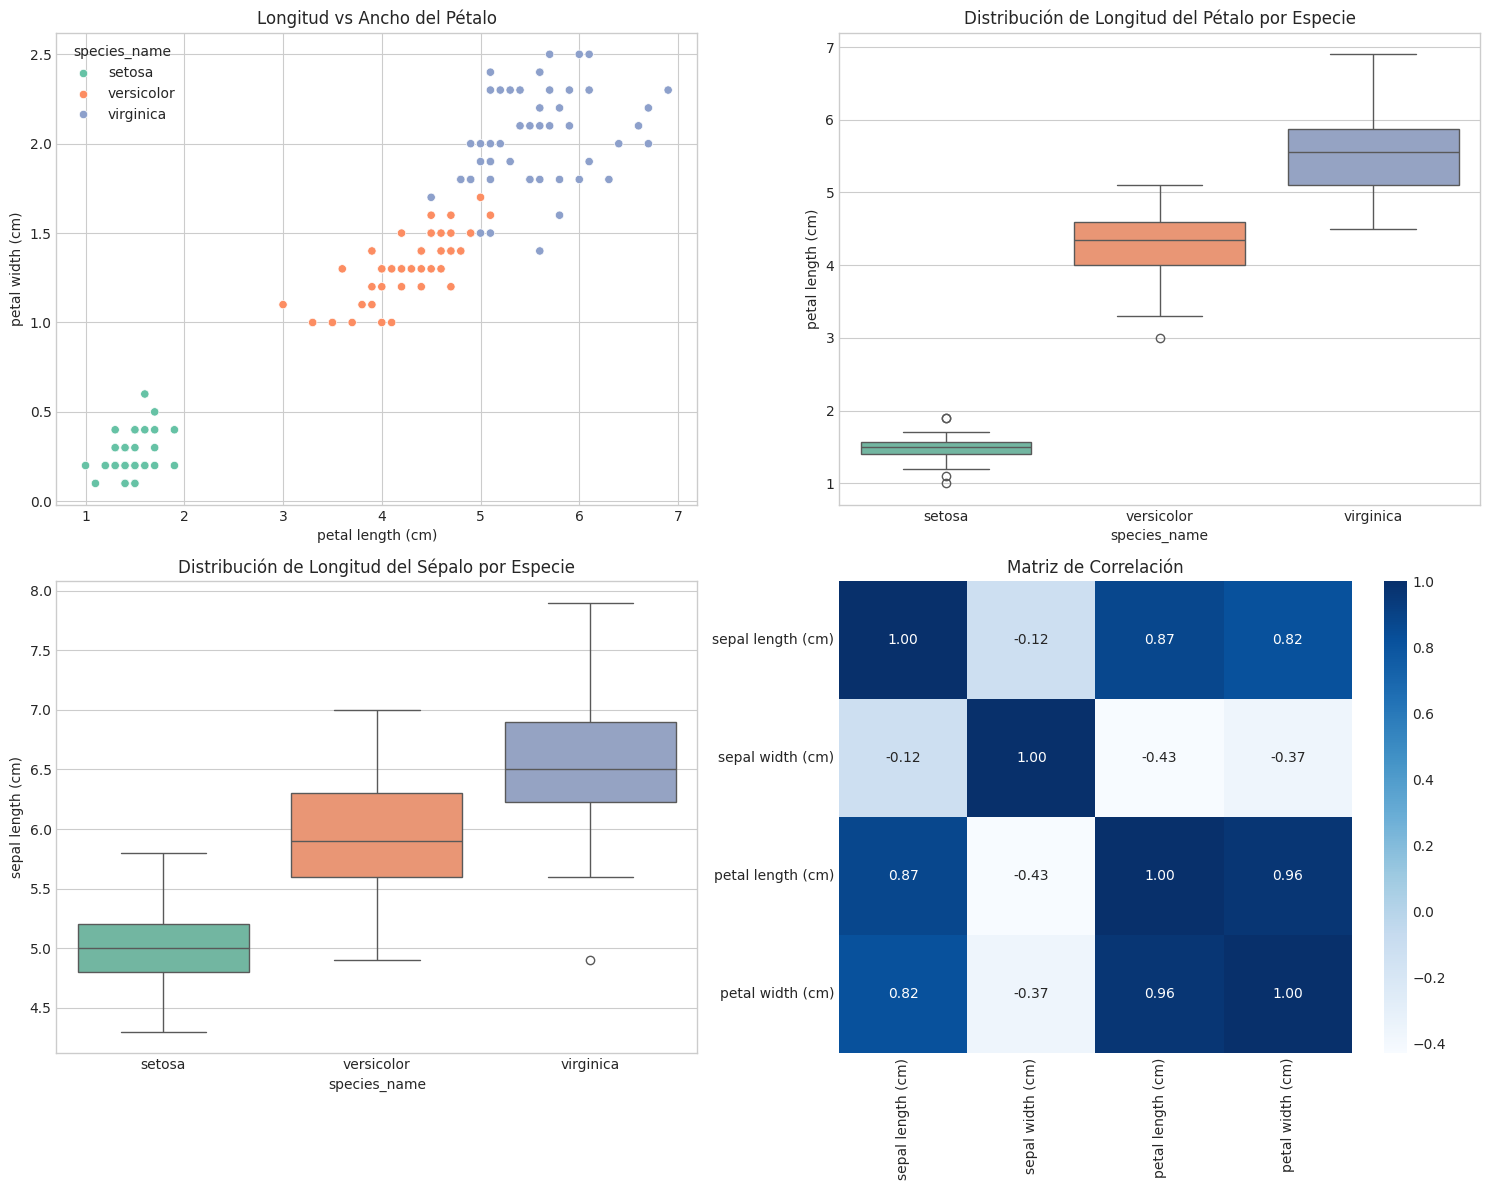

In [0]:
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por especie
# - Distribución de características por especie
# - Boxplots por especie
# - Matriz de correlación

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# ...
# plt.show()

# TODO: Escribe tus observaciones clave sobre separabilidad y correlaciones.

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(
    data=df, 
    x='petal length (cm)', 
    y='petal width (cm)', 
    hue='species_name', 
    palette='Set2', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Longitud vs Ancho del Pétalo')

sns.boxplot(
    data=df, 
    x='species_name', 
    y='petal length (cm)', 
    palette='Set2', 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Distribución de Longitud del Pétalo por Especie')

sns.boxplot(
    data=df, 
    x='species_name', 
    y='sepal length (cm)', 
    palette='Set2', 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Distribución de Longitud del Sépalo por Especie')

numeric_df = df.drop(columns=['species', 'species_name'])
sns.heatmap(
    numeric_df.corr(), 
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()


## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Separa características (X) y etiquetas (y).
# X = ...
# y = ...

# TODO: Divide el dataset en entrenamiento y prueba.
# Pistas:
# - Usa train_test_split
# - Reserva una parte para test
# - Usa random_state para reproducibilidad
# - Considera stratify=y para mantener la proporción de clases

# X_train, X_test, y_train, y_test = train_test_split(...)

# TODO: Comprueba tamaños y distribución de clases en cada conjunto.

X = df[dataset.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("=== Tamaños de los conjuntos ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\n=== Distribución de clases en Entrenamiento (y_train) ===")
print(y_train.value_counts().sort_index())

print("\n=== Distribución de clases en Prueba (y_test) ===")
print(y_test.value_counts().sort_index())


=== Tamaños de los conjuntos ===
X_train: (120, 4)
X_test:  (30, 4)
y_train: (120,)
y_test:  (30,)

=== Distribución de clases en Entrenamiento (y_train) ===
species
0    40
1    40
2    40
Name: count, dtype: int64

=== Distribución de clases en Prueba (y_test) ===
species
0    10
1    10
2    10
Name: count, dtype: int64


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/10/02 15:08:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:08:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:08:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-31cad2192baf4ab5b1415905f1593bd8?o=7474659306803469
2026/10/02 15:08:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

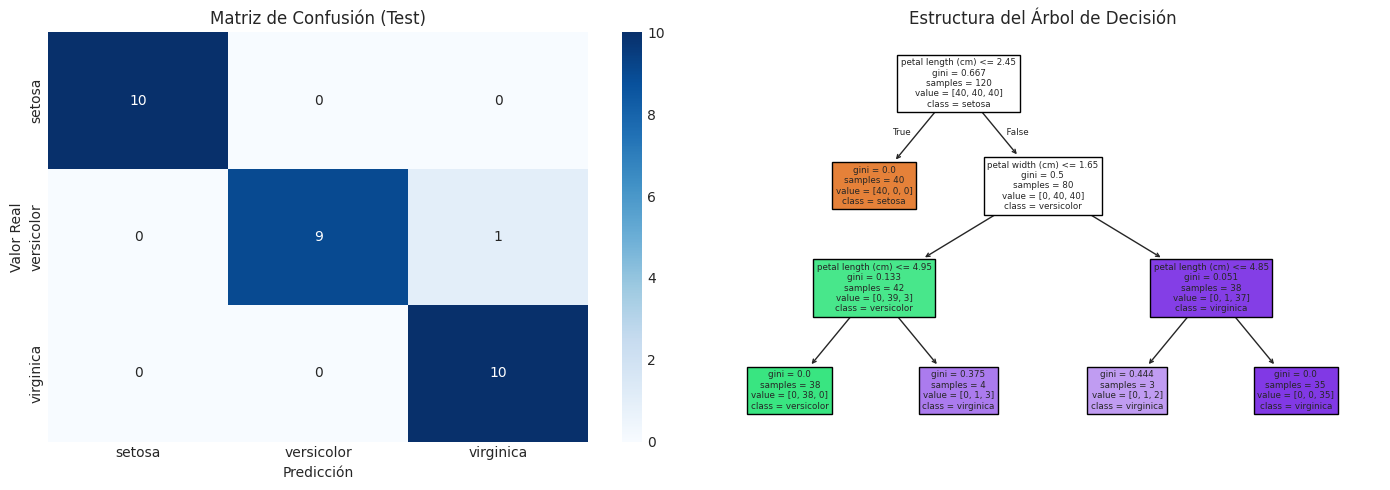

Accuracy Test: 0.9667
Precision Test: 0.9697
Recall Test: 0.9667
F1-Score Test: 0.9666
CV Score Promedio: 0.9333

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [0]:
# ========================================
# TODO: ENTRENAMIENTO CON MLFLOW
# ========================================

# TODO: Activa autologging de MLflow.
# mlflow.sklearn.autolog()

# TODO: Inicia un run con un nombre descriptivo.
# with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
#     TODO: Define hiperparámetros del árbol.
#     max_depth = ...
#     max_features = ...
#     random_state = ...
#
#     TODO: Crea y entrena DecisionTreeClassifier.
#     dt = DecisionTreeClassifier(...)
#     dt.fit(...)
#
#     TODO: Genera predicciones para train y test.
#     y_pred_train = ...
#     y_pred_test = ...
#
#     TODO: Calcula métricas de clasificación.
#     accuracy_test = ...
#     precision_test = ...
#     recall_test = ...
#     f1_test = ...
#
#     TODO: Evalúa con cross-validation.
#     cv_scores = ...
#
#     TODO: Registra métricas/parámetros relevantes en MLflow si no quedan registrados automáticamente.
#
#     TODO: Visualiza matriz de confusión y, opcionalmente, el árbol.
#
#     TODO: Escribe una breve interpretación de los resultados.

mlflow.sklearn.autolog()

with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
    
    max_depth = 3
    max_features = None
    random_state = 42
    
    dt = DecisionTreeClassifier(
        max_depth=max_depth,
        max_features=max_features,
        random_state=random_state
    )
    dt.fit(X_train, y_train)
    
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
    
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
    
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("max_features", max_features)
    mlflow.log_metric("accuracy_test", accuracy_test)
    mlflow.log_metric("precision_test", precision_test)
    mlflow.log_metric("recall_test", recall_test)
    mlflow.log_metric("f1_test", f1_test)
    mlflow.log_metric("cv_scores_mean", cv_scores.mean())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=dataset.target_names, yticklabels=dataset.target_names)
    axes[0].set_title("Matriz de Confusión (Test)")
    axes[0].set_xlabel("Predicción")
    axes[0].set_ylabel("Valor Real")
    
    plot_tree(dt, feature_names=dataset.feature_names, class_names=dataset.target_names, filled=True, ax=axes[1])
    axes[1].set_title("Estructura del Árbol de Decisión")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Accuracy Test: {accuracy_test:.4f}")
    print(f"Precision Test: {precision_test:.4f}")
    print(f"Recall Test: {recall_test:.4f}")
    print(f"F1-Score Test: {f1_test:.4f}")
    print(f"CV Score Promedio: {cv_scores.mean():.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred_test, target_names=dataset.target_names))


El modelo alcanza un 96.67% de precisión (Accuracy) al clasificar correctamente 29 de las 30 muestras, fallando sólamente en una flor versicolor que clasificó como virginica.

La primera regla del árbol (petal length) separa a la especie setosa de forma perfecta con un Gini de 0.0, mientras que las decisiones posteriores se basan en el ancho y largo del pétalo para distinguir versicolor de virginica. Finalmente, con un CV Score de 93.33%, el modelo demuestra ser estable ante nuevos datos.

## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración del dataset Iris
2. [ ] Separación train/test
3. [ ] Entrenamiento de un Árbol de Decisión
4. [ ] Evaluación con métricas de clasificación
5. [ ] Registro del experimento en MLflow
6. [ ] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**TODO: Explica con tus palabras:**
- ¿Qué ventajas tiene un árbol de decisión?
- ¿Qué riesgos tiene respecto a overfitting?
- ¿Cómo interpretarías una matriz de confusión multiclase?

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**TODO:** ¿Qué combinación da el mejor balance entre accuracy y overfitting?

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

**TODO:** ¿Qué flores se confunden más y por qué?

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del ejercicio.

import itertools
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ========================================
# TODO: DESAFÍO 1 - Optimización manual
# ========================================
# configuraciones = [...]
# for config in configuraciones:
#     # Entrena, evalúa y registra cada configuración en MLflow
#     pass

print("DESAFÍO 1 - Optimización Manual")

configuraciones = [
    {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2},
    {'max_depth': 5, 'max_features': 3, 'min_samples_split': 5},
    {'max_depth': 10, 'max_features': 4, 'min_samples_split': 10},
    {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2}
]

for config in configuraciones:
    with mlflow.start_run(run_name=f"Manual_d{config['max_depth']}_f{config['max_features']}"):
        model = DecisionTreeClassifier(**config, random_state=42)
        model.fit(X_train, y_train)
        
        cv_acc = cross_val_score(model, X_train, y_train, cv=5).mean()
        test_acc = accuracy_score(y_test, model.predict(X_test))
        
        mlflow.log_params(config)
        mlflow.log_metrics({"cv_accuracy": cv_acc, "test_accuracy": test_acc})
        print(f"Config: {config} | CV Acc: {cv_acc:.4f} | Test Acc: {test_acc:.4f}")



2026/10/02 15:08:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


DESAFÍO 1 - Optimización Manual


2026/10/02 15:08:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:08:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-a6ee2dfadf2b4abd935f09e3ad236372?o=7474659306803469
2026/10/02 15:09:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:09:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Config: {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2} | CV Acc: 0.9667 | Test Acc: 0.9333


2026/10/02 15:09:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:09:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-4c45e04e852e4ab093a9e72177b140ea?o=7474659306803469
2026/10/02 15:09:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:09:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Config: {'max_depth': 5, 'max_features': 3, 'min_samples_split': 5} | CV Acc: 0.9333 | Test Acc: 0.9667


2026/10/02 15:10:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:10:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-df2b9d5f6841467e954d02f4e8aa3a43?o=7474659306803469
2026/10/02 15:10:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:10:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Config: {'max_depth': 10, 'max_features': 4, 'min_samples_split': 10} | CV Acc: 0.9333 | Test Acc: 0.9667


2026/10/02 15:10:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:10:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-296d74bf544441fa963f78df6d517742?o=7474659306803469
2026/10/02 15:10:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:10:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Config: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2} | CV Acc: 0.9583 | Test Acc: 0.9333


In [0]:
# ========================================
# TODO: DESAFÍO 2 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

print("\nDESAFÍO 2 - Grid Search")

param_grid = {
    'max_depth': [3, 5, 10, None],
    'max_features': [2, 3, 4, 'sqrt'],
    'min_samples_split': [2, 5, 10]
}

with mlflow.start_run(run_name="GridSearchCV_DecisionTree"):
    grid_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring='accuracy'
    )
    grid_search.fit(X_train, y_train)
    
    best_dt = grid_search.best_estimator_
    test_acc_grid = accuracy_score(y_test, best_dt.predict(X_test))
    
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("best_cv_accuracy", grid_search.best_score_)
    mlflow.log_metric("test_accuracy", test_acc_grid)
    
    print(f"Mejores Parámetros: {grid_search.best_params_}")
    print(f"Mejor Score CV: {grid_search.best_score_:.4f}")
    print(f"Accuracy Test: {test_acc_grid:.4f}")



2026/10/02 15:11:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.



DESAFÍO 2 - Grid Search


2026/10/02 15:11:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-04486e4765ba4eeebe97b9b2231f61fb?o=7474659306803469
2026/10/02 15:11:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Mejores Parámetros: {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2}
Mejor Score CV: 0.9667
Accuracy Test: 0.9333


In [0]:
# ========================================
# TODO: DESAFÍO 3 - Comparación de modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena y compara métricas
#     pass

print("\nDESAFÍO 3 - Comparación de Modelos")

modelos = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42)
}

resultados = []

for nombre, mod in modelos.items():
    with mlflow.start_run(run_name=f"Modelo_{nombre}"):
        mod.fit(X_train, y_train)
        preds = mod.predict(X_test)
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='weighted')
        
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        
        resultados.append({"Modelo": nombre, "Accuracy": acc, "F1-Score": f1})
        print(f"Modelo: {nombre:<20} | Accuracy Test: {acc:.4f} | F1-Score: {f1:.4f}")

2026/10/02 15:11:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.



DESAFÍO 3 - Comparación de Modelos


2026/10/02 15:11:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-26203e55974a451face00b800e46633e?o=7474659306803469
2026/10/02 15:11:42 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Modelo: Random Forest        | Accuracy Test: 0.9000 | F1-Score: 0.8997


2026/10/02 15:11:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-0c397bccf5214caa8bd4548b00b2ab80?o=7474659306803469
2026/10/02 15:11:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Modelo: SVM                  | Accuracy Test: 0.9667 | F1-Score: 0.9666


2026/10/02 15:11:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-1318d5bcd8584cd894533256deed092a?o=7474659306803469
2026/10/02 15:11:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Modelo: KNN                  | Accuracy Test: 1.0000 | F1-Score: 1.0000


2026/10/02 15:11:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:11:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-fad89e9e4015404cb579563473e0d108?o=7474659306803469
2026/10/02 15:12:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:12:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

Modelo: Logistic Regression  | Accuracy Test: 0.9667 | F1-Score: 0.9666


In [0]:
# ========================================
# TODO: DESAFÍO 4 - Análisis de errores
# ========================================
# incorrect_indices = ...
# TODO: inspecciona las muestras mal clasificadas.

print("\nDESAFÍO 4 - Análisis de Errores")

y_test_pred = dt.predict(X_test)
incorrect_indices = y_test != y_test_pred

df_errores = X_test[incorrect_indices].copy()
df_errores['Real'] = y_test[incorrect_indices].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_errores['Predicho'] = pd.Series(y_test_pred, index=y_test.index)[incorrect_indices].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Muestras mal clasificadas:")
display(df_errores)

2026/10/02 15:12:04 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.



DESAFÍO 4 - Análisis de Errores
Muestras mal clasificadas:


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Real,Predicho
6.7,3.0,5.0,1.7,versicolor,virginica


2026/10/02 15:12:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.



DESAFÍO 5 - PCA y Límites de Decisión 2D


2026/10/02 15:12:05 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c6c4ff3b80794b16b0ea4aab04ebac65', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 15:12:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 15:12:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-e0a486ad-f654.cloud.databricks.com/ml/experiments/3727837028599435/models/m-b274e240d9ea45768f5623e2aaa8ea35?o=7474659306803469
2026/10/02 15:12:05 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/10/02 15:12:09 WARNING ml

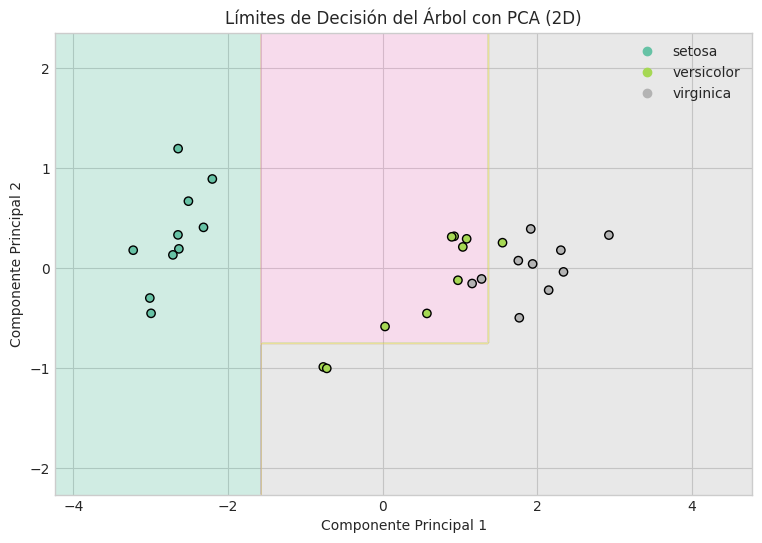

In [0]:
# ========================================
# TODO: DESAFÍO 5 - PCA y visualización 2D
# ========================================
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_pca = ...

print("\nDESAFÍO 5 - PCA y Límites de Decisión 2D")

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

dt_pca = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pca.fit(X_train_pca, y_train)

# Malla para graficar límites de decisión
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
# Se cambia plt.cm.Set2 por el string 'Set2'
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='Set2', edgecolors='k')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Límites de Decisión del Árbol con PCA (2D)")
plt.legend(handles=scatter.legend_elements()[0], labels=list(dataset.target_names))
plt.show()